In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('bird_migration_data.csv')
df.head()

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Excellent,Yes,Storm,Researcher_A,27.0,Failed,No,102,56,Low
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Good,Yes,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low
2,B1002,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,19.448466,...,Fair,No,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High
3,B1003,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,...,Good,Yes,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,Good,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate


In [3]:
df.shape

(10000, 41)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Bird_ID                  10000 non-null  object 
 1   Species                  10000 non-null  object 
 2   Region                   10000 non-null  object 
 3   Habitat                  10000 non-null  object 
 4   Weather_Condition        10000 non-null  object 
 5   Migration_Reason         10000 non-null  object 
 6   Start_Latitude           10000 non-null  float64
 7   Start_Longitude          10000 non-null  float64
 8   End_Latitude             10000 non-null  float64
 9   End_Longitude            10000 non-null  float64
 10  Flight_Distance_km       10000 non-null  float64
 11  Flight_Duration_hours    10000 non-null  float64
 12  Average_Speed_kmph       10000 non-null  float64
 13  Max_Altitude_m           10000 non-null  int64  
 14  Min_Altitude_m         

In [5]:
df.describe()

,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Max_Altitude_m,Min_Altitude_m,Temperature_C,...,Pressure_hPa,Visibility_km,Tag_Battery_Level_%,Signal_Strength_dB,Rest_Stops,Predator_Sightings,Flock_Size,Tag_Weight_g,Recovery_Time_days,Observation_Counts
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.321812,-0.394588,0.084391,0.467617,2504.036134,49.994020,49.953394,5504.80830,500.111800,12.566930,...,1000.440810,10.636970,54.651800,-69.8408,7.380000,4.490200,248.714500,17.605870,60.490800,49.872800
std,51.919190,104.083440,51.709437,103.438134,499.723298,10.026108,5.085296,2595.28577,229.782907,13.073405,...,28.959614,5.504623,25.839271,9.9189,4.023583,2.872826,144.943771,7.200088,34.434028,28.601997
min,-89.999003,-179.993975,-89.998482,-179.902756,527.700000,12.600000,30.430000,1000.00000,100.000000,-10.000000,...,950.000000,1.000000,10.000000,-107.9000,1.000000,0.000000,1.000000,5.000000,1.000000,1.000000
25%,-45.390697,-91.444680,-43.664719,-88.871564,2169.632500,43.200000,46.530000,3277.75000,300.000000,1.200000,...,975.000000,5.900000,32.000000,-76.6000,4.000000,2.000000,124.000000,11.400000,31.000000,25.000000
50%,-0.138849,-0.479892,-0.163116,1.280823,2511.150000,50.050000,50.040000,5521.00000,501.000000,12.500000,...,1000.950000,10.700000,55.000000,-69.8000,7.000000,5.000000,248.000000,17.700000,61.000000,50.000000
75%,44.480926,89.640253,44.957102,91.196076,2841.452500,56.800000,53.360000,7740.25000,698.000000,24.000000,...,1025.500000,15.400000,77.000000,-63.1000,11.000000,7.000000,376.000000,24.000000,91.000000,74.000000
max,89.980302,179.989973,89.989145,179.955036,4428.320000,91.000000,68.950000,9999.00000,899.000000,35.000000,...,1050.000000,20.000000,99.000000,-33.3000,14.000000,9.000000,499.000000,30.000000,119.000000,99.000000


## Data Cleaning


In [6]:
df.isnull().sum()

Bird_ID                       0
Species                       0
Region                        0
Habitat                       0
Weather_Condition             0
Migration_Reason              0
Start_Latitude                0
Start_Longitude               0
End_Latitude                  0
End_Longitude                 0
Flight_Distance_km            0
Flight_Duration_hours         0
Average_Speed_kmph            0
Max_Altitude_m                0
Min_Altitude_m                0
Temperature_C                 0
Wind_Speed_kmph               0
Humidity_%                    0
Pressure_hPa                  0
Visibility_km                 0
Nesting_Success               0
Tag_Battery_Level_%           0
Signal_Strength_dB            0
Migration_Start_Month         0
Migration_End_Month           0
Rest_Stops                    0
Predator_Sightings            0
Tag_Type                      0
Migrated_in_Flock             0
Flock_Size                    0
Food_Supply_Level             0
Tracking

In [7]:
df[df['Interrupted_Reason'].isnull()]

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,Good,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate
16,B1016,Eagle,Asia,Forest,Foggy,Breeding,5.674694,-28.865072,52.433084,-144.416251,...,Excellent,No,NaN,Researcher_C,21.9,Successful,No,79,92,Low
26,B1026,Stork,North America,Grassland,Foggy,Climate Change,-69.598587,-127.420861,0.016276,-69.422883,...,Good,Yes,NaN,Researcher_B,27.1,Successful,Yes,79,85,Low
29,B1029,Hawk,Europe,Wetland,Foggy,Climate Change,-27.990897,-108.960295,-82.658938,-4.235715,...,Excellent,Yes,NaN,Researcher_B,14.7,Failed,No,68,63,High
33,B1033,Crane,Australia,Wetland,Windy,Feeding,27.394341,39.497977,44.993402,82.891035,...,Excellent,Yes,NaN,Researcher_B,14.1,Successful,No,63,53,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9962,B10962,Swallow,Africa,Grassland,Stormy,Climate Change,71.780230,87.605094,32.132491,-18.692104,...,Good,No,NaN,Researcher_C,22.9,Failed,No,97,98,Low
9963,B10963,Warbler,Australia,Wetland,Foggy,Feeding,33.880830,40.124942,-32.596928,1.479616,...,Excellent,Yes,NaN,Researcher_C,5.8,Failed,Yes,62,34,High
9972,B10972,Hawk,North America,Urban,Clear,Climate Change,-15.441805,87.652124,-77.107052,-82.550480,...,Poor,No,NaN,Researcher_B,25.3,Successful,Yes,84,54,Moderate
9974,B10974,Warbler,Europe,Grassland,Stormy,Avoid Predators,-5.178930,69.038143,-0.795902,-137.453050,...,Excellent,Yes,NaN,Researcher_B,11.9,Successful,Yes,45,12,Moderate


In [8]:
#Handling Missing values
df.loc[
    (df['Migration_Interrupted'] == 'No') &
    (df['Interrupted_Reason'].isna()),
    'Interrupted_Reason'
] = 'Not applicable'

df.loc[
    (df['Migration_Interrupted'] == 'Yes') &
    (df['Interrupted_Reason'].isna()),
    'Interrupted_Reason'
] = 'Unknown'

Missing values in the 'Interrupted_Reason' column were handled conditionally. Records where 'Migration_Interrupted' = No were labeled "Not applicable", while records where 'Migration_Interrupted' = Yes but the reason was missing were labeled "Unknown" to distinguish unrecorded information from cases where no interruption occurred.

In [9]:
df[df['Interrupted_Reason'].isnull()]

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Bird_ID                  10000 non-null  object 
 1   Species                  10000 non-null  object 
 2   Region                   10000 non-null  object 
 3   Habitat                  10000 non-null  object 
 4   Weather_Condition        10000 non-null  object 
 5   Migration_Reason         10000 non-null  object 
 6   Start_Latitude           10000 non-null  float64
 7   Start_Longitude          10000 non-null  float64
 8   End_Latitude             10000 non-null  float64
 9   End_Longitude            10000 non-null  float64
 10  Flight_Distance_km       10000 non-null  float64
 11  Flight_Duration_hours    10000 non-null  float64
 12  Average_Speed_kmph       10000 non-null  float64
 13  Max_Altitude_m           10000 non-null  int64  
 14  Min_Altitude_m         

## EDA

## Univariate Analysis

In [19]:
df['Species'].value_counts()

Species
Hawk       1464
Stork      1439
Warbler    1429
Goose      1428
Eagle      1426
Swallow    1423
Crane      1391
Name: count, dtype: int64

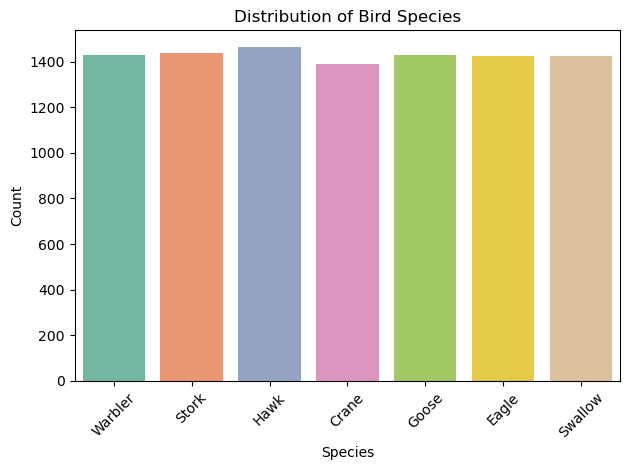

In [20]:
# What is the distribution of 'species' in the dataset?
sns.countplot(data=df, x='Species',hue='Species',palette='Set2')
plt.title('Distribution of Bird Species')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


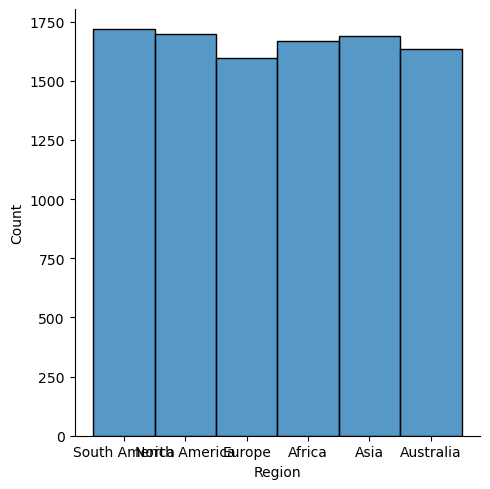

In [21]:
# What is the distribution of Region in the dataset?
sns.displot(data=df,x='Region', kde=False, bins=30)
plt.show()